En este notebook se va a proceder con la limpieza de los datos. Ya se han explorado las variables en el notebook de 01_Auditoria_y_seleccion_variables y se ha llegado a la conclusión de que la disponibilidad de las variables no es homogénea entre las distintas rondas de la ESS, por lo que una elevada proporción de valores ausentes puede deberse tanto a la cobertura temporal de una variable como a la ausencia de respuesta.

Además, en cuanto a los códigos especiales tampoco tienen un único origen: en determinadas variables predominan los casos clasificados como *Not applicable*, mientras que en otras tienen mayor peso categorías como *Refusal, Don't know o No answer*. Esta distinción resulta importante para interpretar correctamente la ausencia de información y evitar tomar decisiones de limpieza únicamente a partir del porcentaje inicial de valores perdidos.

Es por esto que, partiendo de los resultados obtenidos durante la auditoría inicial, en este notebook se llevará a cabo la limpieza y preparación del conjunto de datos.

El proceso comenzará con la recodificación de los códigos especiales identificados en el *codebook* de la ESS, seguida de una nueva evaluación de los valores ausentes. A partir de esta información se tomarán de forma progresiva las decisiones relativas a la selección de variables, tratamiento de los datos y construcción del conjunto de datos final para el análisis.

El dataset original se conservará sin modificaciones y todas las transformaciones se realizarán sobre una copia.


In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import sys
import importlib

In [197]:
# Ruta principal del proyecto
ruta_tfm = "/content/drive/MyDrive/TFM"

# Añadimos la carpeta del proyecto al path de Python
# para poder importar misfunciones.py
if ruta_tfm not in sys.path:
    sys.path.append(ruta_tfm)

In [198]:

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [199]:
ruta_df = "/content/drive/MyDrive/TFM/Datafile-subset.csv"

df_raw = pd.read_csv(ruta_df)

df = df_raw.copy()

/tmp/ipykernel_2801/1128491149.py:3: DtypeWarning: Columns (43) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(ruta_df)


In [200]:
with open("/content/drive/MyDrive/TFM/Datafile-subset codebook.html", "r", encoding="utf-8") as f:
    soup = BeautifulSoup(f, "html.parser")
print(soup.title.text)


        Codebook
    


In [201]:
ruta_diccionario="/content/drive/MyDrive/TFM/Diccionario variables ESS.xlsx"

diccionario = pd.read_excel(ruta_diccionario)

display(diccionario)

,Variable,Nombre,Descripción práctica
0,name,Nombre del dataset,Título del conjunto de datos de procedencia.
1,essround,Ronda ESS,Ronda de la European Social Survey a la que pe...
2,edition,Edición,Versión o edición del archivo de datos utilizado.
3,proddate,Fecha de producción,Fecha de producción de la versión del conjunto...
4,idno,Identificador,Número identificativo del participante dentro ...
5,cntry,País,País en el que se realizó la encuesta.
6,dweight,Peso de diseño,Ponderación que corrige las distintas probabil...
7,pspwght,Peso de postestratificación,Ponderación de postestratificación que incorpo...
8,pweight,Peso poblacional,Ajuste relacionado con el tamaño de la poblaci...
9,anweight,Peso de análisis,Ponderación destinada al análisis de los datos.


In [202]:
import importlib
import misfunciones

importlib.reload(misfunciones)

<module 'misfunciones' from '/content/drive/MyDrive/TFM/misfunciones.py'>

In [203]:
df_original = df.copy()

In [204]:
cod_missing = misfunciones.extraer_cod_missing(
    soup,
    df.columns
)

print(
    "Variables con códigos especiales identificados:",
    len(cod_missing)
)

Variables con códigos especiales identificados: 47


#**1. Recodificación de los códigos especiales y diagnóstico de missings**

La auditoría inicial mostró que determinados códigos numéricos representan respuestas como *Not applicable*, *Refusal*, *Don't know* o *No answer*. Aunque aparecen almacenados como números, la ESS los identifica como valores perdidos.

Por este motivo, estos códigos se recodifican como valores ausentes (NaN) antes de continuar con el análisis.

In [205]:
df_limpio = misfunciones.recodificar_cod_missing(
    df_original,
    cod_missing
)

In [206]:
missing_antes = df_original.isna().sum().sum()
missing_despues = df_limpio.isna().sum().sum()

codigos_recodificados = (
    missing_despues - missing_antes
)

print(f"Missing antes: {missing_antes:,}")
print(f"Missing después: {missing_despues:,}")
print(
    f"Códigos especiales recodificados: "
    f"{codigos_recodificados:,}"
)

Missing antes: 8,105,903
Missing después: 8,622,020
Códigos especiales recodificados: 516,117


**Interpretación de los códigos perdidos después de recodificar**

Tras recodificar los códigos especiales definidos en el codebook, el número total de valores ausentes aumenta de 8.105.903 a 8.622.020. Esto supone la identificación de 516.117 observaciones adicionales que inicialmente no eran reconocidas por Pandas como valores perdidos. El resultado confirma la importancia de interpretar correctamente la codificación original de la ESS antes de realizar cualquier análisis o selección de variables.

Después de este pequeño análisis, queremos contestar a la pregunta: **¿Cómo cambia el porcentaje de valores ausentes de cada variable después de recodificar correctamente los códigos especiales de la ESS?**

Para ello, una vez recodificados los códigos especiales, se recalcula el porcentaje de valores ausentes de cada variable y se compara con la situación original. Esta comparación permite diferenciar entre los valores que ya estaban registrados como ausentes en el archivo y aquellos que inicialmente aparecían como códigos numéricos, pero que el codebook identifica como respuestas especiales. El incremento entre ambos porcentajes permite valorar el efecto real de la recodificación sobre cada variable.

In [207]:
# Porcentaje de missing antes de la recodificación
missing_antes_var = (
    df_original.isna().mean() * 100
)

# Porcentaje de missing después de la recodificación
missing_despues_var = (
    df_limpio.isna().mean() * 100
)

# Tabla comparativa
comparacion_missing = pd.DataFrame({
    "variable": df_original.columns,
    "pct_missing_antes": missing_antes_var.values,
    "pct_missing_despues": missing_despues_var.values
})

# Incremento provocado por los códigos especiales
comparacion_missing["incremento"] = (
    comparacion_missing["pct_missing_despues"]
    - comparacion_missing["pct_missing_antes"]
)

# Ordenamos por el porcentaje final de missing
comparacion_missing = comparacion_missing.sort_values(
    "pct_missing_despues",
    ascending=False
).reset_index(drop=True)

# Redondeamos para visualizar
display(
    comparacion_missing.round(2)
)

,variable,pct_missing_antes,pct_missing_despues,incremento
0,grspay,91.21,97.60,6.40
1,dfcnswk,91.21,96.43,5.22
2,hlpcowk,81.51,92.80,11.30
3,hlthrwk,81.51,92.79,11.28
4,hwkstrs,91.21,92.58,1.37
5,frshrst,91.21,91.25,0.04
6,hinctnt,78.06,82.95,4.89
7,actvgrs,81.51,81.61,0.10
8,clmrlx,81.51,81.60,0.09
9,gdsprt,81.51,81.59,0.08


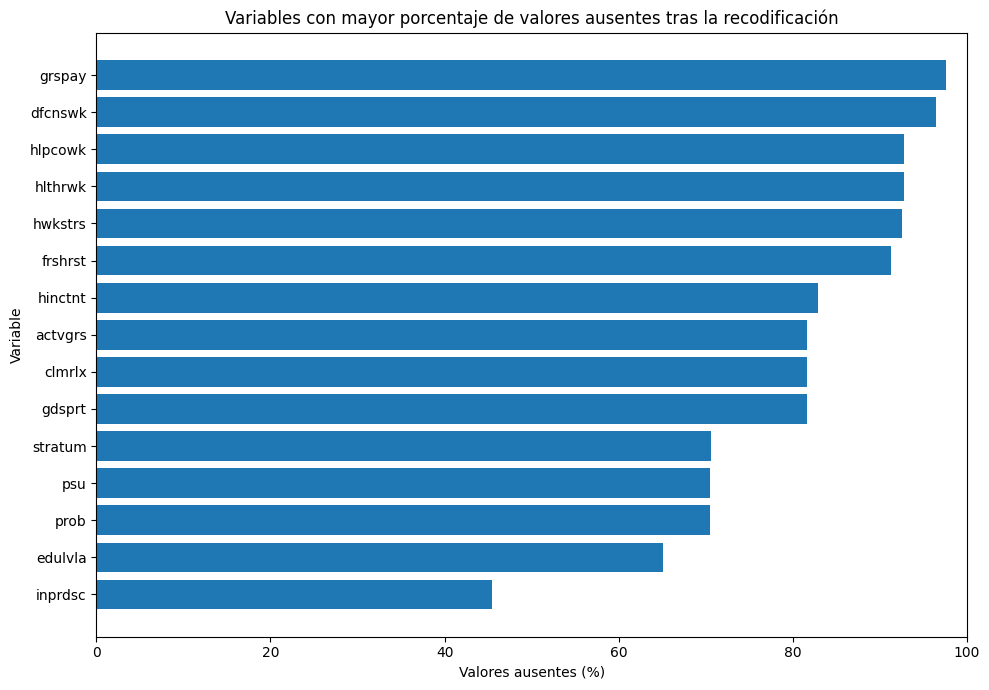

In [208]:
top15_missing = (
    comparacion_missing
    .head(15)
    .sort_values("pct_missing_despues")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top15_missing["variable"],
    top15_missing["pct_missing_despues"],
    label="Missing final"
)

plt.xlabel("Valores ausentes (%)")
plt.ylabel("Variable")
plt.title(
    "Variables con mayor porcentaje de valores ausentes "
    "tras la recodificación"
)

plt.xlim(0, 100)
plt.tight_layout()
plt.show()

Tras la recodificación de los códigos especiales, se observan diferencias importantes en la proporción de valores ausentes entre las variables. Algunas presentan porcentajes superiores al 80-90 %, especialmente aquellas relacionadas con condiciones laborales, ingresos o bienestar en el trabajo. Sin embargo, estos porcentajes no deben interpretarse de forma aislada como un problema de calidad de los datos. La auditoría previa mostró que parte de esta ausencia está relacionada con la cobertura desigual de las variables entre rondas y, en determinados casos, con situaciones en las que la pregunta no resulta aplicable. Por tanto, la selección o exclusión de variables no se realizará únicamente mediante los valores ausentes, sino considerando conjuntamente su cobertura temporal, el origen de la ausencia y su relevancia para los objetivos del estudio.

Por tanto, con el objetivo de interpretar correctamente la ausencia de información, se combina el porcentaje de valores ausentes obtenido tras la recodificación con la cobertura de cada variable a lo largo de las rondas de la ESS. Para cada variable se registra el porcentaje de valores ausentes original, el porcentaje final tras la recodificación, el incremento asociado a los códigos especiales y el número de rondas en las que se encuentra disponible. Esta información permite distinguir entre variables cuya elevada ausencia está relacionada principalmente con una cobertura temporal limitada y aquellas que, aun estando disponibles en varias rondas, presentan una proporción relevante de respuestas no válidas o no aplicables.

In [209]:
importlib.reload(misfunciones)

diagnostico_variables = misfunciones.diagnostico_variables(
    df_original,
    df_limpio
)

display(diagnostico_variables.round(2))

,variable,n_rondas,rondas,n_validos,pct_validos,pct_missing_antes,pct_missing_despues,incremento
0,grspay,1,2,12960,2.40,91.21,97.60,6.40
1,dfcnswk,1,2,19318,3.57,91.21,96.43,5.22
2,hlpcowk,2,"2, 5",38904,7.20,81.51,92.80,11.30
3,hlthrwk,2,"2, 5",38982,7.21,81.51,92.79,11.28
4,hwkstrs,1,2,40109,7.42,91.21,92.58,1.37
5,frshrst,1,2,47331,8.75,91.21,91.25,0.04
6,hinctnt,3,"1, 2, 3",92177,17.05,78.06,82.95,4.89
7,actvgrs,2,"2, 5",99453,18.39,81.51,81.61,0.10
8,clmrlx,2,"2, 5",99492,18.40,81.51,81.60,0.09
9,gdsprt,2,"2, 5",99555,18.41,81.51,81.59,0.08


En esta función creada en misfunciones.py, lo que se pretende es hacer un diagnóstico completo de las variables. La tabla muestra una clara diferencia en la disponibilidad de las variables del conjunto de datos. Parte de los elevados porcentajes de valores ausentes se explica por la cobertura desigual de las variables entre las rondas de la ESS. Las variables incluidas únicamente en módulos específicos, como *grspay* o *dfcnswk*, disponibles únicamente en la ronda 2, presentan porcentajes de valores ausentes superiores al 90% cuando se considera el conjunto completo de observaciones.

Por otro lado, la recodificación permite detectar variables cuyo nivel de ausencia estaba parcialmente oculto por los códigos especiales. Destaca *emplrel*, cuyo porcentaje de valores ausentes aumenta del 0,61% al 11,47%, aunque la variable está presente en las once rondas. Como se comprobó durante la auditoría, este incremento está relacionado principalmente con respuestas clasificadas como *Not applicable*.

En contraste, variables como *health, gndr, hlthhmp, sclmeet, happy, yrbrn o hincfel* presentan cobertura en las once rondas y mantienen más del 97% de observaciones válidas tras la recodificación. En conjunto, estos resultados muestran que el porcentaje global de valores ausentes no es suficiente por sí solo para decidir la exclusión de una variable, ya que debe interpretarse junto con su cobertura en cada ronda y el origen de la ausencia.

En el siguiente gráfico se pretende presentar de manera visual la disponibilidad de respuestas válidas por variable y ronda.

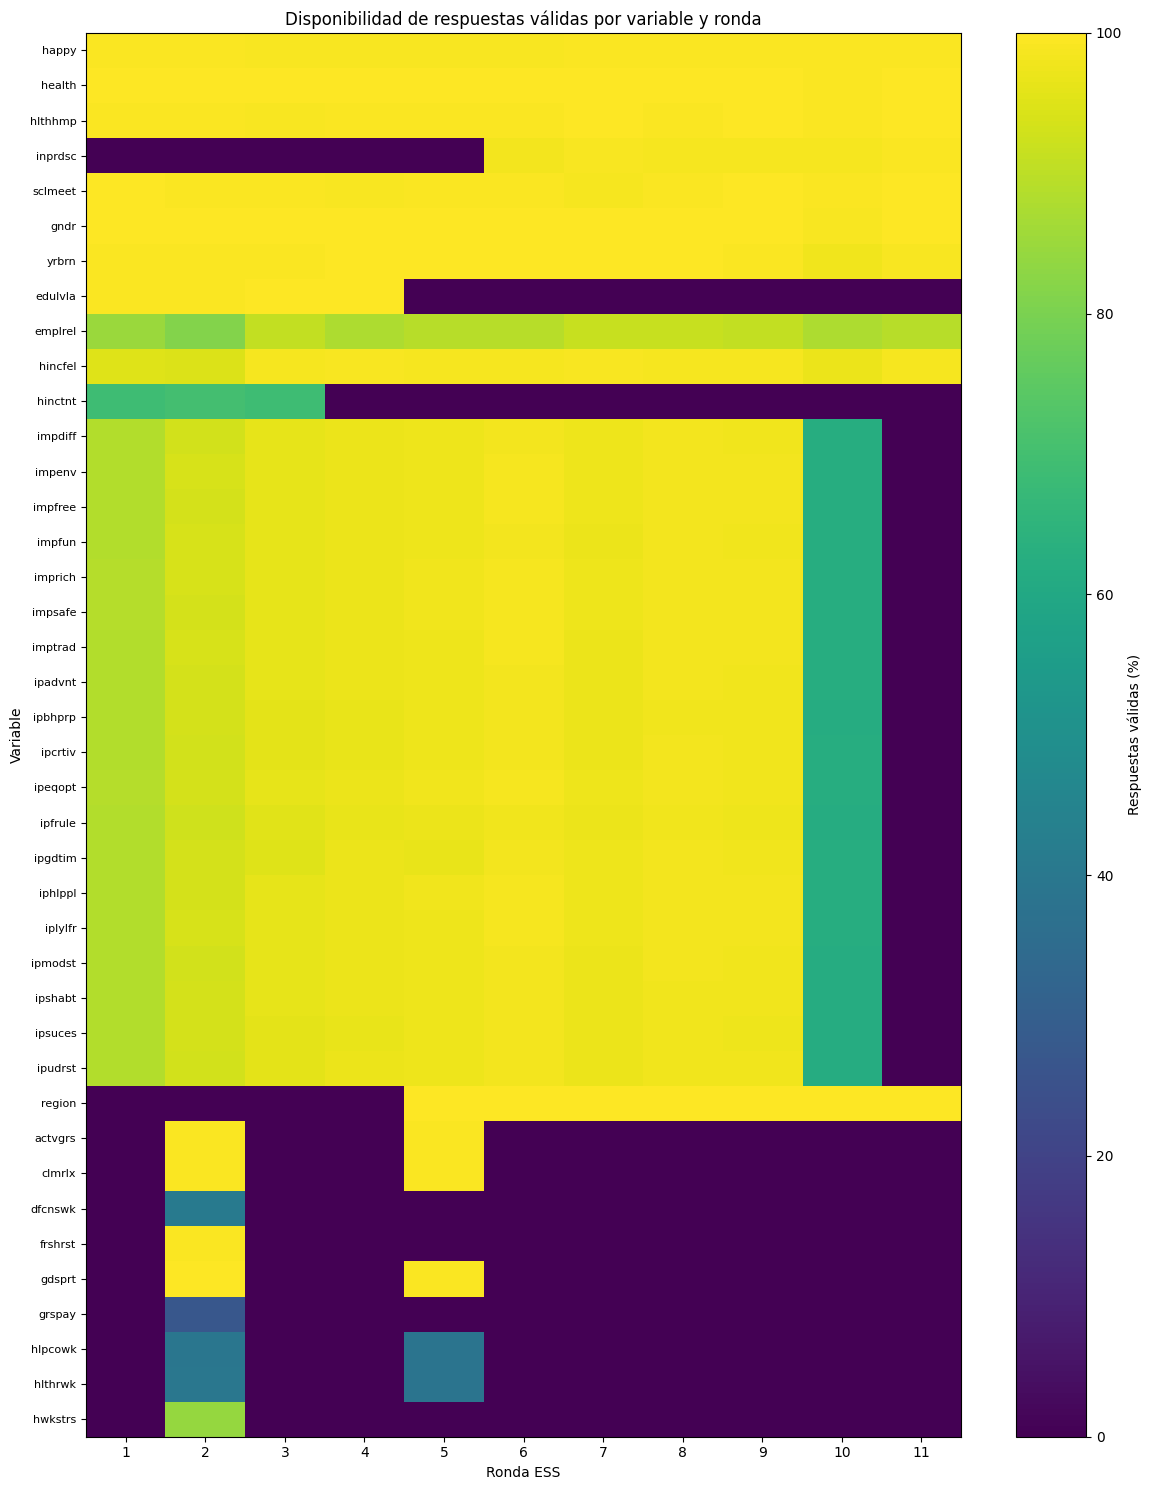

In [210]:
# Variables técnicas que no necesitamos visualizar
variables_tecnicas = [
    "name", "edition", "proddate", "idno",
    "dweight", "pspwght", "pweight", "anweight",
    "prob", "stratum", "psu"
]

# Variables de análisis
variables_grafico = [
    col for col in df_limpio.columns
    if col not in variables_tecnicas
    and col not in ["essround", "cntry"]
]

# Porcentaje de respuestas válidas por ronda
validos_ronda = (
    df_limpio
    .groupby("essround")[variables_grafico]
    .count()
    .T
)

n_ronda = df_limpio.groupby("essround").size()

pct_validos_ronda = (
    validos_ronda
    .div(n_ronda, axis=1)
    .mul(100)
)

# Gráfico
plt.figure(figsize=(12, 15))

plt.imshow(
    pct_validos_ronda.values,
    aspect="auto"
)

plt.colorbar(label="Respuestas válidas (%)")

plt.xticks(
    range(len(pct_validos_ronda.columns)),
    pct_validos_ronda.columns
)

plt.yticks(
    range(len(pct_validos_ronda.index)),
    pct_validos_ronda.index,
    fontsize=8
)

plt.xlabel("Ronda ESS")
plt.ylabel("Variable")
plt.title("Disponibilidad de respuestas válidas por variable y ronda")

plt.tight_layout()
plt.show()

El mapa de calor muestra de forma visual las diferencias en la disponibilidad de las variables entre las distintas rondas de la ESS. Se observa un grupo de variables con una disponibilidad elevada y estable durante todo el periodo, mientras que otras únicamente fueron recogidas en determinadas rondas. Esto permite comprobar que una parte importante de los valores ausentes detectados anteriormente se debe a la propia estructura temporal de la encuesta y no necesariamente a la falta de respuesta de los participantes.

#**2. Selección y depuración de variables**

Una vez analizada la disponibilidad de las variables entre las distintas rondas de la ESS y realizada la identificación y recodificación de los códigos especiales de respuesta, se procede a evaluar la calidad y disponibilidad efectiva de las variables antes de seleccionar aquellas que formarán parte del análisis.

Como no todas las variables aparecen en todas las rondas de la ESS, mirar únicamente el porcentaje de missing sobre toda la base de datos puede llevar a conclusiones equivocadas. Una variable puede tener muchos valores vacíos simplemente porque esa pregunta solo se hizo en algunas rondas, y no porque tenga un problema de calidad.

Por este motivo, se calcula también la cobertura efectiva. En este caso, en lugar de comparar los datos válidos con toda la muestra, se tienen en cuenta únicamente las rondas en las que aparece cada variable. Así podemos ver qué porcentaje de respuestas válidas tiene realmente cuando la pregunta está disponible.

De esta forma podemos diferenciar mejor las variables que tienen muchos missing porque aparecen en pocas rondas de aquellas que realmente tienen una pérdida importante de información.

In [211]:
resultados_cobertura = []

for _, fila in diagnostico_variables.iterrows():

    variable = fila["variable"]

    # Rondas en las que la variable tiene información
    rondas_var = [
        int(r.strip())
        for r in str(fila["rondas"]).split(",")
        if r.strip()
    ]

    # Nº de personas pertenecientes a esas rondas
    n_elegibles = df_limpio[
        df_limpio["essround"].isin(rondas_var)
    ].shape[0]

    # Nº de respuestas válidas
    n_validos = df_limpio.loc[
        df_limpio["essround"].isin(rondas_var),
        variable
    ].notna().sum()

    # Cobertura efectiva
    pct_cobertura_efectiva = (
        n_validos / n_elegibles * 100
        if n_elegibles > 0 else 0
    )

    resultados_cobertura.append({
        "variable": variable,
        "n_elegibles": n_elegibles,
        "pct_cobertura_efectiva": pct_cobertura_efectiva
    })


cobertura = pd.DataFrame(resultados_cobertura)

diagnostico = diagnostico_variables.merge(
    cobertura,
    on="variable",
    how="left"
)

diagnostico["pct_cobertura_efectiva"] = (
    diagnostico["pct_cobertura_efectiva"].round(2)
)

diagnostico[
    [
        "variable",
        "n_rondas",
        "rondas",
        "n_validos",
        "n_elegibles",
        "pct_validos",
        "pct_cobertura_efectiva",
        "pct_missing_despues"
    ]
].sort_values(
    "pct_cobertura_efectiva"
)

,variable,n_rondas,rondas,n_validos,n_elegibles,pct_validos,pct_cobertura_efectiva,pct_missing_despues
0,grspay,1,2,12960,47537,2.397021,27.26,97.602979
2,hlpcowk,2,"2, 5",38904,99995,7.195503,38.91,92.804497
3,hlthrwk,2,"2, 5",38982,99995,7.209930,38.98,92.790070
1,dfcnswk,1,2,19318,47537,3.572968,40.64,96.427032
6,hinctnt,3,"1, 2, 3",92177,132896,17.048630,69.36,82.951370
4,hwkstrs,1,2,40109,47537,7.418375,84.37,92.581625
36,emplrel,11,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11",478663,540671,88.531288,88.53,11.468712
16,ipfrule,10,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10",449539,490555,83.144648,91.64,16.855352
18,ipsuces,10,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10",450491,490555,83.320726,91.83,16.679274
19,ipgdtim,10,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10",450661,490555,83.352168,91.87,16.647832


Al comparar el porcentaje global de valores válidos con la cobertura efectiva se observan diferencias importantes. Algunas variables presentan un porcentaje global bajo porque únicamente están disponibles en determinadas rondas, aunque dentro de ellas tienen una cantidad de respuestas muy elevada. Es el caso, por ejemplo, de *frshrst*, que presenta un 8,75 % de datos válidos sobre el conjunto completo, pero alcanza una cobertura del 99,57 % dentro de la ronda en la que está disponible.

Por otro lado, variables como *grspay, hlpcowk, hlthrwk o dfcnswk* mantienen una cobertura baja incluso teniendo en cuenta únicamente las rondas en las que aparecen. En estos casos sí existe una pérdida importante de información.

Por tanto, para seleccionar las variables no se tendrá en cuenta únicamente el porcentaje de missing global, sino también su cobertura dentro de las rondas disponibles y su utilidad para el objetivo del trabajo.

A partir de la cobertura efectiva calculada, el siguiente paso es identificar qué variables tienen una buena cantidad de información y cuáles podrían necesitar una revisión. Sin embargo, antes de establecer unos límites concretos para clasificarlas, es conveniente observar cómo se distribuyen los porcentajes de cobertura. De esta forma, los límites no se eligen de manera arbitraria, sino teniendo en cuenta el comportamiento de las propias variables. El siguiente gráfico permite ordenar las variables según su cobertura efectiva y observar si existen diferencias o grupos claros que puedan servir como referencia para establecer posteriormente los criterios de selección.

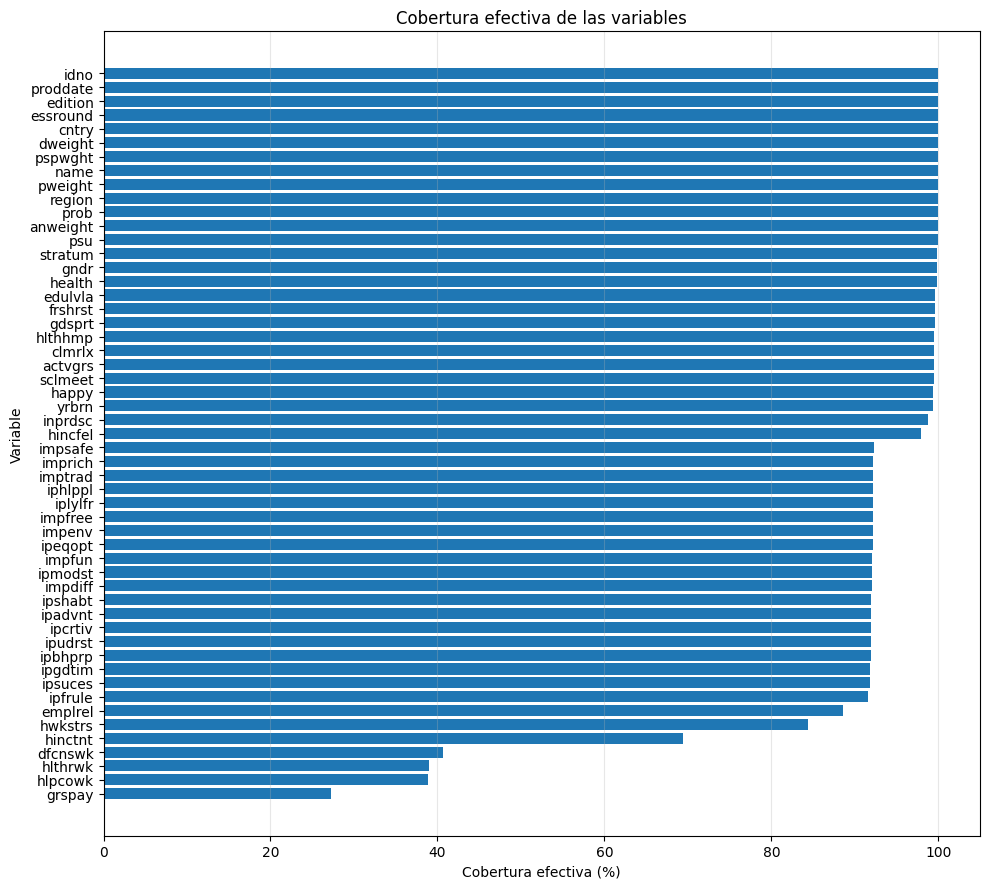

In [212]:
# Ordenamos las variables por cobertura efectiva
cobertura_ordenada = diagnostico.sort_values(
    "pct_cobertura_efectiva",
    ascending=True
)

plt.figure(figsize=(10, 9))

plt.barh(
    cobertura_ordenada["variable"],
    cobertura_ordenada["pct_cobertura_efectiva"]
)

plt.xlabel("Cobertura efectiva (%)")
plt.ylabel("Variable")
plt.title("Cobertura efectiva de las variables")

plt.xlim(0, 105)
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

El gráfico muestra que la mayoría de las variables presentan una cobertura efectiva elevada, generalmente superior al 90 %. Esto indica que, cuando estas variables están disponibles en una ronda, la mayor parte de los participantes tienen una respuesta válida.

También se observa un pequeño grupo de variables con una cobertura bastante más baja: *grspay, hlpcowk, hlthrwk y dfcnswk* presentan valores inferiores al 50 %, mientras que *hinctnt* se sitúa alrededor del 69 %. Por otro lado, *hwkstrs y emplrel* presentan valores más elevados, aunque algo inferiores al resto de variables.

Estos resultados permiten identificar de forma más clara qué variables pueden necesitar una revisión antes de incluirlas en el análisis, sin descartar aquellas que presentan muchos valores ausentes únicamente porque fueron incluidas en pocas rondas.

Antes de estudiar la relación de las variables con la felicidad, se excluyen aquellas cuya función dentro de la ESS es identificar observaciones o versiones del fichero, así como las variables relacionadas con el diseño muestral y la ponderación. Estas variables no se eliminan por su porcentaje de valores perdidos ni por su relación estadística con *happy*, sino porque no representan características de los individuos que se quieran utilizar para explicar su felicidad. Su identificación se realiza a partir de la documentación y el codebook de la ESS.

Las variables *cntry y essround* se mantienen, ya que permiten identificar el país y la ronda de la encuesta y pueden recoger diferencias geográficas y temporales.

In [213]:
#Variables que no forman parte del análisis del bienestar
excluir = [
    "idno", "name", "edition", "proddate",
    "dweight", "pspwght", "pweight", "anweight",
    "prob", "stratum", "psu"
]

# Variables candidatas para el análisis
variables_candidatas = [
    col for col in df_limpio.columns
    if col not in variables_tecnicas
]

print("Variables iniciales:", df_limpio.shape[1])
print("Variables técnicas excluidas:", len(variables_tecnicas))
print("Variables candidatas:", len(variables_candidatas))

Variables iniciales: 53
Variables técnicas excluidas: 11
Variables candidatas: 42


Una vez excluidas las variables técnicas y de diseño, se obtienen 42 variables candidatas. Antes de analizar su capacidad explicativa, se estudia la disponibilidad conjunta de cada variable con la variable objetivo *happy*. Este paso permite conocer la muestra real sobre la que podría evaluarse la relación de cada predictor con la variable objetivo, evitando basar la selección únicamente en el porcentaje global de valores perdidos.

In [214]:
# Disponibilidad conjunta de cada variable con happy

resultados = []

for variable in variables_candidatas:

    if variable == "happy":
        continue

    casos_comunes = df_limpio[["happy", variable]].dropna().shape[0]

    resultados.append({
        "variable": variable,
        "n_comunes_happy": casos_comunes,
        "pct_comunes_happy": casos_comunes / df_limpio["happy"].notna().sum() * 100
    })

disponibilidad_happy = (
    pd.DataFrame(resultados)
    .sort_values("pct_comunes_happy", ascending=False)
    .reset_index(drop=True)
)

disponibilidad_happy

,variable,n_comunes_happy,pct_comunes_happy
0,essround,537218,100.000000
1,cntry,537218,100.000000
2,health,536563,99.878076
3,gndr,536401,99.847920
4,hlthhmp,534854,99.559955
5,sclmeet,534701,99.531475
6,yrbrn,533952,99.392053
7,hincfel,526361,97.979033
8,emplrel,475993,88.603323
9,impsafe,450028,83.770090


**Relación de las variables con la felicidad**

Una vez analizada la disponibilidad conjunta de cada variable con *happy*, se estudia la información que aporta cada una sobre la felicidad mediante *Mutual Information*.

Esta medida permite detectar relaciones tanto lineales como no lineales entre las variables y la felicidad. A diferencia de una correlación tradicional, puede aplicarse a variables con diferentes características, por lo que resulta adecuada como primera aproximación para comparar los posibles predictores.

El objetivo de este análisis no es eliminar automáticamente variables mediante un umbral determinado, sino obtener un ranking que permita identificar cuáles presentan una mayor relación con la variable objetivo.

In [215]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

resultados_mi = []

for variable in variables_candidatas:

    if variable == "happy":
        continue

    # Casos donde existen tanto la variable como happy
    datos = df_limpio[[variable, "happy"]].dropna().copy()

    X = datos[[variable]]
    y = datos["happy"].astype(int)

    # Si la variable no es numérica, codificación automática
    if not pd.api.types.is_numeric_dtype(X[variable]):
        encoder = LabelEncoder()
        X[variable] = encoder.fit_transform(X[variable].astype(str))

    mi = mutual_info_classif(
        X,
        y,
        discrete_features="auto",
        random_state=42
    )[0]

    resultados_mi.append({
        "variable": variable,
        "mutual_information": mi
    })

ranking_mi = (
    pd.DataFrame(resultados_mi)
    .merge(disponibilidad_happy, on="variable", how="left")
    .sort_values("mutual_information", ascending=False)
    .reset_index(drop=True)
)

ranking_mi

/tmp/ipykernel_2801/2826141608.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[variable] = encoder.fit_transform(X[variable].astype(str))
/tmp/ipykernel_2801/2826141608.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[variable] = encoder.fit_transform(X[variable].astype(str))


,variable,mutual_information,n_comunes_happy,pct_comunes_happy
0,gdsprt,0.139372,98859,18.402027
1,hincfel,0.095075,526361,97.979033
2,clmrlx,0.085791,98792,18.389555
3,region,0.079590,348957,64.956312
4,health,0.078275,536563,99.878076
5,actvgrs,0.077457,98757,18.383040
6,grspay,0.074630,12917,2.404424
7,cntry,0.071550,537218,100.000000
8,hinctnt,0.068312,91793,17.086732
9,frshrst,0.043033,47067,8.761248


**Selección según disponibilidad temporal**

El análisis mediante *Mutual Information* permite obtener una primera aproximación a la relación existente entre cada variable y la felicidad. Sin embargo, los resultados deben interpretarse teniendo en cuenta que las variables no están disponibles en las mismas rondas de la ESS y, por tanto, las estimaciones se han obtenido a partir de muestras diferentes.

Por ejemplo, algunas de las variables con mayor *Mutual Information* únicamente aparecen en una o dos rondas, mientras que otras están disponibles durante todo el periodo analizado. Compararlas directamente podría llevar a seleccionar variables con una relación elevada con la felicidad pero que solo representan una parte concreta de la muestra y del periodo estudiado.

Dado que el objetivo del trabajo es desarrollar un modelo general de predicción e interpretación de la felicidad utilizando las 11 rondas disponibles, se decide utilizar en el modelo principal aquellas variables presentes en todas ellas. De esta forma se mantiene la comparabilidad temporal y se evita que la selección dependa de un porcentaje de cobertura establecido de manera arbitraria. Las variables disponibles únicamente en determinadas rondas no se consideran irrelevantes, sino que quedan fuera del modelo principal debido a su menor disponibilidad temporal.

In [216]:
# Variables disponibles en las 11 rondas
variables_11_rondas = diagnostico_variables.loc[
    diagnostico_variables["n_rondas"] == df_limpio["essround"].nunique(),
    "variable"
].tolist()

# Quitamos únicamente las variables técnicas ya identificadas
variables_modelo = [
    v for v in variables_11_rondas
    if v not in variables_tecnicas
]

variables_modelo

['emplrel',
 'hincfel',
 'yrbrn',
 'happy',
 'sclmeet',
 'hlthhmp',
 'health',
 'gndr',
 'cntry',
 'essround']

In [217]:
# Separamos la variable objetivo de los posibles predictores
predictores = [
    v for v in variables_modelo
    if v != "happy"
]

# Muestra con información completa en todas las variables seleccionadas
df_modelo_completo = df_limpio[
    ["happy"] + predictores
].dropna().copy()

print("Observaciones iniciales:", len(df_limpio))
print("Observaciones completas:", len(df_modelo_completo))

print(
    "Porcentaje de muestra conservada:",
    round(len(df_modelo_completo) / len(df_limpio) * 100, 2),
    "%"
)

Observaciones iniciales: 540671
Observaciones completas: 465463
Porcentaje de muestra conservada: 86.09 %


**Definición de la muestra analítica**

Una vez seleccionadas las variables disponibles en las 11 rondas, se analiza el efecto que tendría trabajar únicamente con observaciones completas para todas ellas. De las 540.671 observaciones iniciales, 465.463 presentan información completa para la variable objetivo y los posibles predictores seleccionados, lo que supone conservar el 86,09 % de la muestra original.

Dado que la pérdida de observaciones es limitada y la muestra resultante continúa siendo suficientemente amplia, se decide trabajar con casos completos en lugar de aplicar técnicas de imputación. De esta forma, todas las variables podrán evaluarse sobre una misma muestra y se evita introducir valores estimados en esta fase del análisis.

In [218]:
resultados_mi_final = []

for variable in predictores:

    X = df_modelo_completo[[variable]].copy()
    y = df_modelo_completo["happy"].astype(int)

    # Codificación automática si la variable no es numérica
    if not pd.api.types.is_numeric_dtype(X[variable]):
        encoder = LabelEncoder()
        X[variable] = encoder.fit_transform(X[variable].astype(str))

    mi = mutual_info_classif(
        X,
        y,
        discrete_features="auto",
        random_state=42
    )[0]

    resultados_mi_final.append({
        "variable": variable,
        "mutual_information": mi
    })

ranking_mi_final = (
    pd.DataFrame(resultados_mi_final)
    .sort_values("mutual_information", ascending=False)
    .reset_index(drop=True)
)

ranking_mi_final

,variable,mutual_information
0,hincfel,0.093959
1,health,0.077409
2,cntry,0.074612
3,hlthhmp,0.036564
4,sclmeet,0.036070
5,emplrel,0.014879
6,gndr,0.012936
7,yrbrn,0.008578
8,essround,0.005646


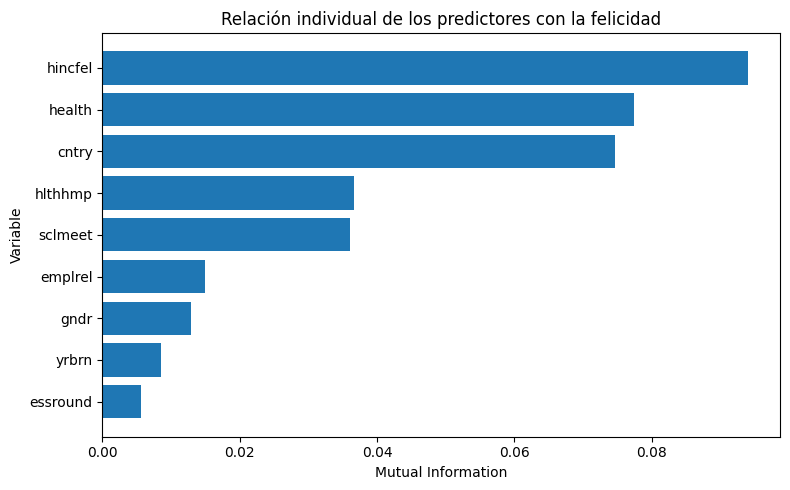

In [219]:
ranking_plot = ranking_mi_final.sort_values(
    "mutual_information",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    ranking_plot["variable"],
    ranking_plot["mutual_information"]
)

plt.xlabel("Mutual Information")
plt.ylabel("Variable")
plt.title("Relación individual de los predictores con la felicidad")

plt.tight_layout()
plt.show()

**Selección final de predictores**

Una vez definida una muestra común de 465.463 observaciones, se calcula nuevamente la *Mutual Information* para comparar todos los posibles predictores bajo las mismas condiciones. Los resultados muestran que *hincfel, health y cntry* presentan la mayor relación individual con la felicidad, seguidas por *hlthhmp y sclmeet*. Por su parte, *emplrel, gndr, yrbrn y essround* muestran valores inferiores.

La *Mutual Information* se utiliza como herramienta exploratoria para conocer la capacidad informativa individual de las variables, pero no como un criterio automático de eliminación. Dado que el conjunto resultante contiene únicamente nueve predictores, se mantienen todos para la fase de modelización. De esta forma, será posteriormente el comportamiento de los modelos y las técnicas de interpretabilidad las que permitan determinar qué variables tienen una mayor contribución a la predicción de la felicidad.

#**3. Análisis exploratorio de los datos (EDA)**

Una vez finalizada la selección y depuración de variables, se realiza un análisis exploratorio sobre la muestra definitiva de 465.463 observaciones. El objetivo es conocer la distribución de la variable objetivo *happy* y analizar su comportamiento en relación con los predictores seleccionados antes de comenzar la modelización. Este análisis permitirá identificar patrones generales, posibles diferencias entre grupos y relaciones que posteriormente podrán ser contrastadas mediante los modelos de Machine Learning.

In [220]:
# Estadísticos descriptivos de la variable objetivo

df_modelo_completo["happy"].describe()

,happy
count,465463.000000
mean,7.233971
std,1.993250
min,0.000000
25%,6.000000
50%,8.000000
75%,9.000000
max,10.000000


In [221]:
distribucion_happy = (
    df_modelo_completo["happy"]
    .value_counts()
    .sort_index()
    .reset_index()
)

distribucion_happy.columns = ["happy", "frecuencia"]

distribucion_happy["porcentaje"] = (
    distribucion_happy["frecuencia"]
    / len(df_modelo_completo)
    * 100
)

distribucion_happy

,happy,frecuencia,porcentaje
0,0.0,3386,0.727448
1,1.0,3099,0.665789
2,2.0,6619,1.422025
3,3.0,12573,2.701181
4,4.0,15621,3.356013
5,5.0,48462,10.411569
6,6.0,41292,8.871167
7,7.0,84591,18.173518
8,8.0,127759,27.447724
9,9.0,74275,15.957230


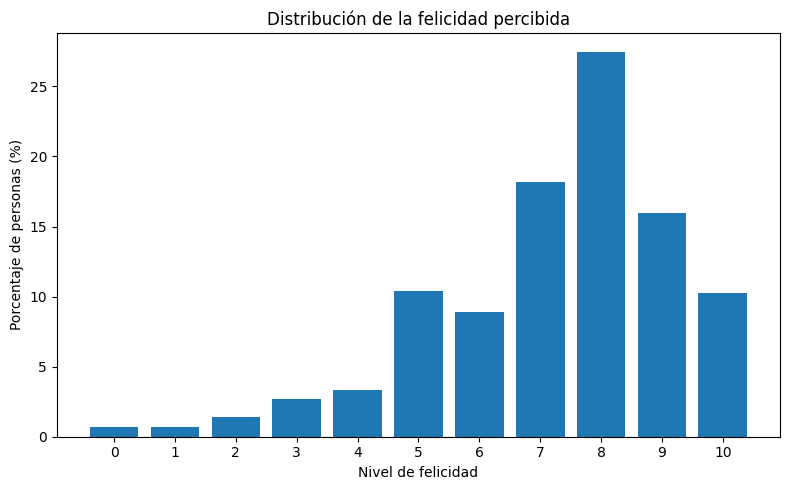

In [222]:
plt.figure(figsize=(8, 5))

plt.bar(
    distribucion_happy["happy"],
    distribucion_happy["porcentaje"]
)

plt.xlabel("Nivel de felicidad")
plt.ylabel("Porcentaje de personas (%)")
plt.title("Distribución de la felicidad percibida")

plt.xticks(range(0, 11))
plt.tight_layout()
plt.show()

La distribución de la felicidad muestra una clara concentración en los valores altos de la escala. La media se sitúa en 7,23 puntos y la mediana en 8, mientras que el valor más frecuente es 8, seleccionado por el 27,45 % de los participantes. Las puntuaciones 7, 8 y 9 concentran conjuntamente más del 60 % de las respuestas, mientras que los niveles más bajos presentan frecuencias considerablemente menores.

Esta distribución indica que la percepción de felicidad en la muestra es, en general, elevada y presenta una asimetría hacia la izquierda, debido a la mayor concentración de observaciones en la parte alta de la escala.

Dado que *happy* se mide originalmente en una escala de 0 a 10, se mantiene su información original y la predicción se plantea como un problema de regresión, evitando establecer categorías o puntos de corte adicionales.

Ahora se va a analizar la relación entre la felicidad y los principales predictores identificados mediante *Mutual Information*. Este análisis permite observar cómo varía el nivel medio de felicidad en función de diferentes características de los participantes antes de aplicar los modelos predictivos.

In [223]:
# Felicidad media según percepción de los ingresos

happy_hincfel = (
    df_modelo_completo
    .groupby("hincfel", observed=True)["happy"]
    .agg(
        felicidad_media="mean",
        n="count"
    )
    .reset_index()
)

happy_hincfel

,hincfel,felicidad_media,n
0,1.0,8.060795,139287
1,2.0,7.340568,209468
2,3.0,6.360841,84339
3,4.0,5.261238,32369


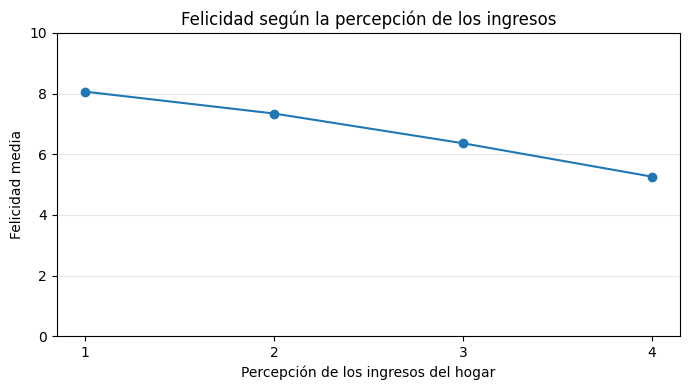

In [224]:
# Felicidad media según percepción de los ingresos

plt.figure(figsize=(7, 4))

plt.plot(
    happy_hincfel["hincfel"],
    happy_hincfel["felicidad_media"],
    marker="o"
)

plt.xlabel("Percepción de los ingresos del hogar")
plt.ylabel("Felicidad media")
plt.title("Felicidad según la percepción de los ingresos")

plt.xticks(happy_hincfel["hincfel"])
plt.ylim(0, 10)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [225]:
# Felicidad media según salud percibida

happy_health = (
    df_modelo_completo
    .groupby("health", observed=True)["happy"]
    .agg(
        felicidad_media="mean",
        n="count"
    )
    .reset_index()
)

happy_health

,health,felicidad_media,n
0,1.0,8.057719,103034
1,2.0,7.470393,196678
2,3.0,6.721539,126499
3,4.0,5.707937,32671
4,5.0,4.697310,6581


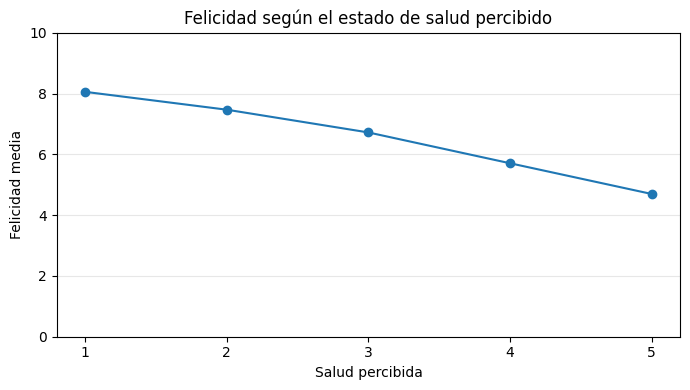

In [226]:
# Felicidad media según salud percibida

plt.figure(figsize=(7, 4))

plt.plot(
    happy_health["health"],
    happy_health["felicidad_media"],
    marker="o"
)

plt.xlabel("Salud percibida")
plt.ylabel("Felicidad media")
plt.title("Felicidad según el estado de salud percibido")

plt.xticks(happy_health["health"])
plt.ylim(0, 10)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Los resultados muestran una relación clara entre la percepción de la situación económica y la felicidad. La felicidad media disminuye progresivamente a medida que empeora la valoración de los ingresos del hogar, pasando de 8,06 puntos en el grupo con una situación económica más favorable a 5,26 puntos entre quienes presentan mayores dificultades. Un patrón similar se observa en la salud percibida. Las personas que declaran una mejor salud presentan una felicidad media de 8,06 puntos, mientras que esta disminuye progresivamente hasta 4,70 puntos entre quienes valoran peor su estado de salud.

Estos resultados son coherentes con el análisis previo de *Mutual Information*, donde *hincfel y health* fueron las variables individuales con mayor información respecto a *happy*. No obstante, estas relaciones son descriptivas y no permiten establecer relaciones causales.

In [227]:
# Felicidad media según frecuencia de relaciones sociales

happy_sclmeet = (
    df_modelo_completo
    .groupby("sclmeet", observed=True)["happy"]
    .agg(
        felicidad_media="mean",
        n="count"
    )
    .reset_index()
)

# Felicidad media según limitaciones relacionadas con la salud

happy_hlthhmp = (
    df_modelo_completo
    .groupby("hlthhmp", observed=True)["happy"]
    .agg(
        felicidad_media="mean",
        n="count"
    )
    .reset_index()
)

display(happy_sclmeet)
display(happy_hlthhmp)

,sclmeet,felicidad_media,n
0,1.0,5.287992,8594
1,2.0,6.178478,41501
2,3.0,6.849556,46017
3,4.0,7.213826,95877
4,5.0,7.349787,83914
5,6.0,7.587530,124014
6,7.0,7.639551,65546


,hlthhmp,felicidad_media,n
0,1.0,6.013014,28661
1,2.0,6.756678,94718
2,3.0,7.468423,342084


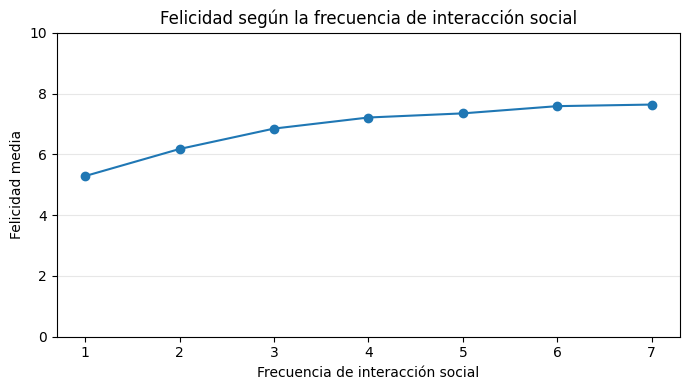

In [228]:
plt.figure(figsize=(7, 4))

plt.plot(
    happy_sclmeet["sclmeet"],
    happy_sclmeet["felicidad_media"],
    marker="o"
)

plt.xlabel("Frecuencia de interacción social")
plt.ylabel("Felicidad media")
plt.title("Felicidad según la frecuencia de interacción social")

plt.xticks(happy_sclmeet["sclmeet"])
plt.ylim(0, 10)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Las relaciones sociales muestran una asociación positiva con la felicidad percibida. A medida que aumenta la frecuencia de contacto social, la felicidad media también aumenta, pasando de 5,29 puntos en el nivel más bajo de interacción social a 7,64 puntos en el nivel más alto. En el caso de las limitaciones relacionadas con la salud, se observa el patrón contrario. Las personas con mayores limitaciones presentan una felicidad media más reducida, mientras que aquellas sin limitaciones alcanzan valores superiores. Este resultado refuerza la importancia de la salud y de la capacidad funcional dentro del análisis de la felicidad. Al igual que en los análisis anteriores, estas relaciones deben interpretarse como asociaciones descriptivas y no como relaciones causales.

Ahora que ya se conoce como influyen las variables *hincfel, health, sclmeet y hlthhmp* en relación con la felicidades, se pretende analizar cuales son las diferencias en la felicidades de los diferentes países de Europa para entender si existen diferencias apreciables en la felicidad media según el país de residencia.

In [229]:
# Felicidad media por país

happy_cntry = (
    df_modelo_completo
    .groupby("cntry", observed=True)["happy"]
    .agg(
        felicidad_media="mean",
        n="count"
    )
    .reset_index()
    .sort_values("felicidad_media", ascending=False)
)

happy_cntry

,cntry,felicidad_media,n
8,DK,8.332685,11822
19,IS,8.201813,4633
4,CH,8.074671,17075
11,FI,8.069566,20283
27,NO,7.976551,16717
26,NL,7.820032,18770
33,SE,7.792247,18392
22,LU,7.787757,2483
2,BE,7.745973,16577
18,IL,7.563882,13384


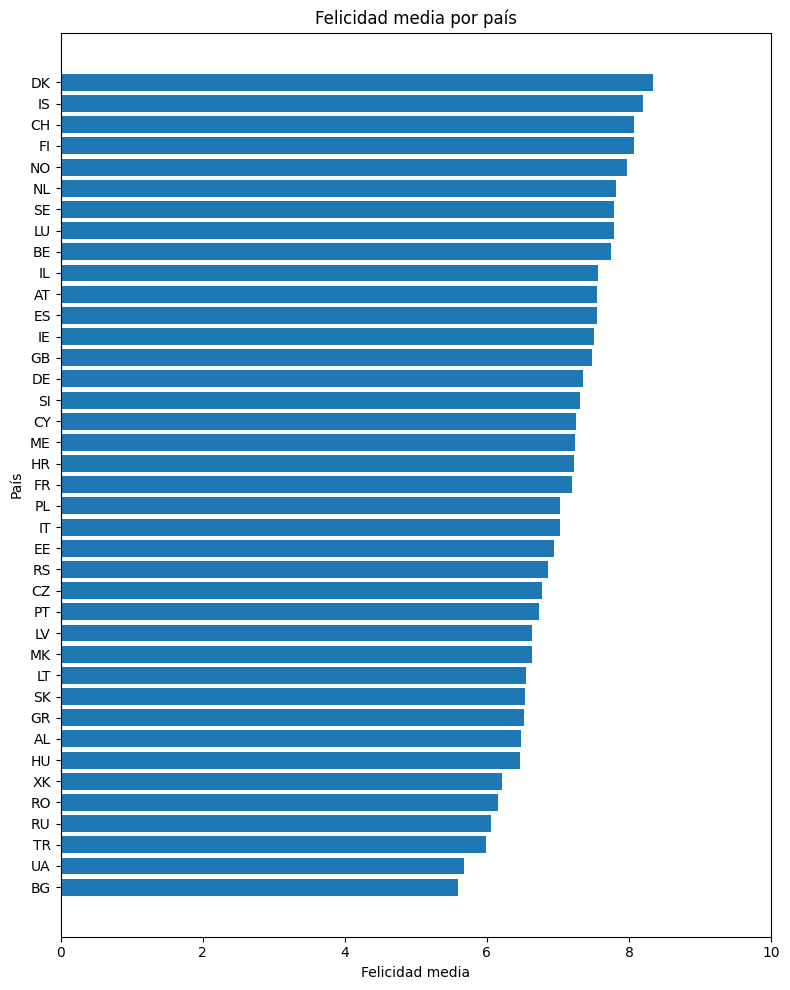

In [230]:
# Gráfico de felicidad media por país

happy_cntry_plot = happy_cntry.sort_values(
    "felicidad_media",
    ascending=True
)

plt.figure(figsize=(8, 10))

plt.barh(
    happy_cntry_plot["cntry"],
    happy_cntry_plot["felicidad_media"]
)

plt.xlabel("Felicidad media")
plt.ylabel("País")
plt.title("Felicidad media por país")

plt.xlim(0, 10)
plt.tight_layout()
plt.show()

Los resultados muestran diferencias en los niveles medios de felicidad entre los países incluidos en la muestra. Los valores más elevados se observan en Dinamarca (8,33), Islandia (8,20), Suiza (8,07) y Finlandia (8,07), mientras que los niveles más bajos aparecen en Bulgaria (5,60), Ucrania (5,68) y Turquía (5,99). La diferencia entre los extremos supera los 2,7 puntos en una escala de 0 a 10, lo que muestra la existencia de una variabilidad geográfica relevante en la percepción de la felicidad. Este resultado es coherente con la posición de cntry entre las variables con mayor *Mutual Information*.

No obstante, estas diferencias deben interpretarse con cautela, ya que el número de observaciones no es igual para todos los países y su presencia tampoco es necesariamente homogénea a lo largo de las distintas rondas. Por tanto, el análisis permite identificar diferencias entre países, pero no establecer que el país sea por sí mismo la causa de dichas diferencia.

Por últimp, se quiere comprobar si la felicidad media se mantiene relativamente estable o cambia entre rondas,es decir, la evolución de la felicidad entre rondas.

In [231]:
# Felicidad media por ronda

happy_round = (
    df_modelo_completo
    .groupby("essround", observed=True)["happy"]
    .agg(
        felicidad_media="mean",
        n="count"
    )
    .reset_index()
)

happy_round

,essround,felicidad_media,n
0,1,7.389270,35266
1,2,7.256722,37488
2,3,7.150691,37640
3,4,6.989445,48317
4,5,6.981871,45452
5,6,7.115826,47554
6,7,7.384534,35807
7,8,7.454559,39777
8,9,7.443169,44008
9,10,7.173200,50462


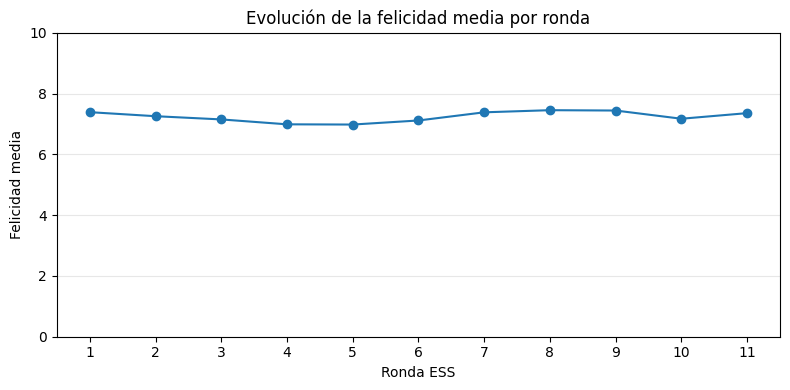

In [232]:
plt.figure(figsize=(8, 4))

plt.plot(
    happy_round["essround"],
    happy_round["felicidad_media"],
    marker="o"
)

plt.xlabel("Ronda ESS")
plt.ylabel("Felicidad media")
plt.title("Evolución de la felicidad media por ronda")

plt.xticks(happy_round["essround"])
plt.ylim(0, 10)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

La evolución de la felicidad media presenta una relativa estabilidad a lo largo de las 11 rondas analizadas. Los valores oscilan entre aproximadamente 6,98 y 7,45 puntos, manteniéndose durante todo el periodo alrededor de los 7 puntos.

Se observa un ligero descenso durante las primeras rondas, seguido de una recuperación a partir de la ronda 6. Las rondas 8 y 9 presentan los valores medios más elevados, mientras que en la ronda 10 se observa un nuevo descenso, seguido de una recuperación en la ronda 11.

En conjunto, las diferencias entre rondas son reducidas en comparación con las observadas en otros factores, lo que resulta coherente con el bajo valor de *Mutual Information* obtenido previamente para *essround*. No obstante, se mantiene esta variable en la modelización para permitir que los modelos tengan en cuenta posibles diferencias temporales.

En conjunto, el análisis exploratorio muestra que la felicidad presenta relaciones especialmente claras con la percepción de los ingresos y el estado de salud. También se observan diferencias relacionadas con la frecuencia de las relaciones sociales, las limitaciones de salud y el país, mientras que las variaciones entre rondas son más reducidas. Estos resultados permiten obtener una primera aproximación a los factores asociados con la felicidad, que serán analizados conjuntamente en la fase de modelización.



#**4. Preparación de los datos para Machine Learning**

Para desarrollar y evaluar los modelos predictivos, la muestra se divide en un conjunto de entrenamiento y un conjunto de prueba. El primero se utilizará para entrenar los modelos, mientras que el segundo se reservará exclusivamente para evaluar su capacidad de generalización sobre observaciones no utilizadas durante el entrenamiento.

Se utiliza una división del 80 % para entrenamiento y 20 % para prueba, manteniendo una semilla fija para garantizar la reproducibilidad de los resultados.

In [233]:
from sklearn.model_selection import train_test_split

# Variable objetivo
y = df_modelo_completo["happy"]

# Variables predictoras
X = df_modelo_completo.drop(columns="happy")

# División entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (372370, 9)
Prueba: (93093, 9)


Antes de entrenar los modelos es necesario preparar las variables predictoras. En particular, las variables categóricas deben transformarse a un formato que pueda ser utilizado por los algoritmos de *Machine Learning*. Para ello se utiliza *One-Hot Encoding*, que transforma las diferentes categorías en variables binarias sin establecer un orden artificial entre ellas. El proceso se integra dentro del preprocesamiento del modelo, permitiendo que las transformaciones se ajusten únicamente con los datos de entrenamiento y evitando así posibles fugas de información (data leakage).

In [234]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Variable categórica nominal
variables_categoricas = ["cntry"]

# Resto de variables
variables_numericas = [
    col for col in X_train.columns
    if col not in variables_categoricas
]

# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            variables_categoricas
        )
    ],
    remainder="passthrough"
)

print("Variables categóricas:", variables_categoricas)
print("Resto de variables:", variables_numericas)

Variables categóricas: ['cntry']
Resto de variables: ['emplrel', 'hincfel', 'yrbrn', 'sclmeet', 'hlthhmp', 'health', 'gndr', 'essround']


#**5. Modelización**

##**5.1. Regresión lineal**

Como primera aproximación se emplea un modelo de regresión lineal con el objetivo de establecer una referencia sencilla e interpretable para la predicción del nivel de felicidad (happy). El modelo se integra en un pipeline junto con el preprocesamiento definido previamente, garantizando que las transformaciones necesarias se apliquen de forma consistente a los conjuntos de entrenamiento y prueba.

El rendimiento se evaluará mediante tres métricas: el error absoluto medio (MAE), la raíz del error cuadrático medio (RMSE) y el coeficiente de determinación (R²). Estas métricas permitirán cuantificar el error de predicción y determinar la proporción de variabilidad de la felicidad explicada por el modelo.

In [235]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Pipeline: preprocesamiento + modelo
modelo_lineal = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("modelo", LinearRegression())
    ]
)

# Entrenamiento
modelo_lineal.fit(X_train, y_train)

# Predicciones
y_pred_lineal = modelo_lineal.predict(X_test)

# Métricas
mae_lineal = mean_absolute_error(y_test, y_pred_lineal)
rmse_lineal = np.sqrt(mean_squared_error(y_test, y_pred_lineal))
r2_lineal = r2_score(y_test, y_pred_lineal)

print(f"MAE: {mae_lineal:.4f}")
print(f"RMSE: {rmse_lineal:.4f}")
print(f"R²: {r2_lineal:.4f}")

MAE: 1.2960
RMSE: 1.7078
R²: 0.2614


El modelo de regresión lineal obtiene un MAE de 1,296 y un RMSE de 1,708, lo que supone una desviación media aproximada de 1,3 puntos en la escala de felicidad. El coeficiente de determinación (R² = 0,261) indica que las variables incluidas permiten explicar alrededor del 26,1 % de la variabilidad observada en la felicidad. Estos resultados constituyen una línea base (*baseline*) para evaluar posteriormente modelos capaces de capturar relaciones no lineales e interacciones más complejas entre los predictores.

##**5.2 Modelo Random Forest**

Tras establecer la regresión lineal como modelo de referencia, se aplica un modelo Random Forest Regressor. Este algoritmo permite capturar relaciones no lineales e interacciones entre las variables explicativas que un modelo lineal puede no representar adecuadamente. Su rendimiento se evaluará sobre el mismo conjunto de prueba y mediante las mismas métricas (MAE, RMSE y R²), permitiendo una comparación directa con el modelo base.

In [236]:
from sklearn.ensemble import RandomForestRegressor

# Pipeline: preprocesamiento + Random Forest optimizado
modelo_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("modelo", RandomForestRegressor(
            n_estimators=50,
            max_depth=15,
            min_samples_leaf=5,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Entrenamiento
modelo_rf.fit(X_train, y_train)

# Predicciones
y_pred_rf = modelo_rf.predict(X_test)

# Métricas
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE: {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²: {r2_rf:.4f}")

MAE: 1.2890
RMSE: 1.7031
R²: 0.2655


El modelo Random Forest obtiene un MAE de 1,289 y un RMSE de 1,703, con un coeficiente de determinación R² de 0,266. Estos resultados suponen una ligera mejora respecto a la regresión lineal, cuyo R² fue de 0,261. Sin embargo, la diferencia entre ambos modelos es reducida, por lo que el incremento de complejidad del Random Forest no se traduce, en esta configuración, en una mejora sustancial de la capacidad predictiva.

##**5.3 Gradient Boosting**

Como tercera aproximación se emplea un modelo de *gradient boosting*, basado en la construcción secuencial de árboles que tratan de corregir progresivamente los errores de las iteraciones anteriores. Se utiliza *HistGradientBoostingRegressor*, un algoritmo especialmente adecuado para conjuntos de datos de gran tamaño. Para garantizar su compatibilidad con el preprocesamiento aplicado, la matriz resultante de la codificación de las variables categóricas se transforma a formato denso antes del entrenamiento. Su rendimiento se evaluará mediante MAE, RMSE y R², utilizando la misma partición de entrenamiento y prueba que en los modelos anteriores para garantizar una comparación homogénea.

In [237]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import FunctionTransformer

# Conversión de matriz sparse a dense
to_dense = FunctionTransformer(
    lambda x: x.toarray() if hasattr(x, "toarray") else x,
    accept_sparse=True
)

# Pipeline: preprocesamiento + conversión a dense + modelo
modelo_hgb = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("to_dense", to_dense),
        ("modelo", HistGradientBoostingRegressor(
            max_iter=200,
            learning_rate=0.1,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]
)

# Entrenamiento
modelo_hgb.fit(X_train, y_train)

# Predicciones
y_pred_hgb = modelo_hgb.predict(X_test)

# Métricas
mae_hgb = mean_absolute_error(y_test, y_pred_hgb)
rmse_hgb = np.sqrt(mean_squared_error(y_test, y_pred_hgb))
r2_hgb = r2_score(y_test, y_pred_hgb)

print(f"MAE: {mae_hgb:.4f}")
print(f"RMSE: {rmse_hgb:.4f}")
print(f"R²: {r2_hgb:.4f}")

MAE: 1.2707
RMSE: 1.6825
R²: 0.2832


El modelo HistGradientBoosting obtiene un MAE de 1,271, un RMSE de 1,683 y un R² de 0,283, presentando el mejor rendimiento de los tres modelos evaluados. La mejora respecto a la regresión lineal y al Random Forest indica que la incorporación de relaciones no lineales permite aumentar moderadamente la capacidad predictiva. No obstante, el modelo explica aproximadamente el 28,3 % de la variabilidad observada en la felicidad, lo que sugiere que una parte importante del bienestar subjetivo depende de factores adicionales no recogidos por las variables incluidas en el modelo.

Es por eso y, con el objetivo de seleccionar el modelo con mayor capacidad predictiva, se comparan los resultados obtenidos por la regresión lineal, Random Forest e HistGradientBoosting sobre el mismo conjunto de prueba. La comparación se realiza mediante MAE, RMSE y R², de forma que valores inferiores de MAE y RMSE y valores superiores de R² indican un mejor rendimiento.

##**5.4. Comparación de los modelos**

Una vez entrenados los tres algoritmos, se comparan sus resultados sobre el mismo conjunto de prueba mediante las métricas MAE, RMSE y R². Esta comparación permite seleccionar el modelo con mejor capacidad predictiva para los análisis posteriores.

In [243]:
comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal",
        "Random Forest",
        "HistGradientBoosting"
    ],
    "MAE": [
        mae_lineal,
        mae_rf,
        mae_hgb
    ],
    "RMSE": [
        rmse_lineal,
        rmse_rf,
        rmse_hgb
    ],
    "R²": [
        r2_lineal,
        r2_rf,
        r2_hgb
    ]
})

comparacion_modelos = (
    comparacion_modelos
    .sort_values("R²", ascending=False)
    .reset_index(drop=True)
)

comparacion_modelos.round(4)

,Modelo,MAE,RMSE,R²
0,HistGradientBoosting,1.2707,1.6825,0.2832
1,Random Forest,1.2890,1.7031,0.2655
2,Regresión Lineal,1.2960,1.7078,0.2614


##**5.5 Análisis de robustez mediante un conjunto ampliado de predictores**

Con el objetivo de comprobar si la incorporación de información adicional puede mejorar la capacidad predictiva, se realiza un análisis de robustez ampliando el conjunto de variables. La selección principal prioriza la comparabilidad temporal y utiliza predictores disponibles en las once rondas de la ESS. Sin embargo, este criterio puede excluir variables potencialmente informativas con una elevada cobertura global.

Para este análisis complementario se consideran variables disponibles en al menos diez rondas y con una cobertura efectiva mínima del 90 %. Debido a que algunas de estas variables presentan valores ausentes en determinadas rondas, se aplica imputación de la mediana en las variables numéricas y de la categoría más frecuente en las variables categóricas. De esta forma se conservan las observaciones de las once rondas.

Este análisis se plantea como una comprobación de robustez y no como una sustitución del modelo principal, ya que incorpora un conjunto diferente de predictores y un tratamiento adicional de los valores ausentes. Su objetivo es determinar si el aumento de información disponible produce una mejora sustancial del rendimiento predictivo.

In [238]:
# Variables disponibles en al menos 10 rondas
# y con una cobertura efectiva mínima del 90 %

variables_ampliadas = diagnostico.loc[
    (diagnostico["n_rondas"] >= 10) &
    (diagnostico["pct_cobertura_efectiva"] >= 90),
    "variable"
].tolist()

# Eliminamos variables técnicas
variables_ampliadas = [
    v for v in variables_ampliadas
    if v not in variables_tecnicas
]

# La variable objetivo no puede utilizarse como predictor
predictores_ampliados = [
    v for v in variables_ampliadas
    if v != "happy"
]

print("Número de predictores:", len(predictores_ampliados))
print("\nPredictores seleccionados:")
print(predictores_ampliados)

Número de predictores: 27

Predictores seleccionados:
['ipfrule', 'ipsuces', 'ipgdtim', 'ipudrst', 'ipbhprp', 'ipcrtiv', 'ipshabt', 'ipadvnt', 'impdiff', 'ipmodst', 'impfun', 'ipeqopt', 'impfree', 'impenv', 'iplylfr', 'iphlppl', 'imptrad', 'imprich', 'impsafe', 'hincfel', 'yrbrn', 'sclmeet', 'hlthhmp', 'health', 'gndr', 'cntry', 'essround']


El modelo ampliado incorpora 27 predictores seleccionados mediante un criterio objetivo de disponibilidad en al menos diez rondas y una cobertura efectiva mínima del 90 %. Para conservar el mayor número posible de observaciones, los valores ausentes de los predictores se tratan mediante imputación dentro del pipeline de preprocesamiento. La variable objetivo (*happy*) no se imputa y únicamente se eliminan las observaciones en las que esta no se encuentra disponible.

Para evaluar esta especificación ampliada se utiliza nuevamente *HistGradientBoosting*, manteniendo el mismo algoritmo y los mismos hiperparámetros empleados en el modelo principal.

In [239]:
# Selección de variables para el modelo ampliado
columnas_ampliadas = ["happy"] + predictores_ampliados

df_ampliado = df_limpio[columnas_ampliadas].copy()

# Eliminamos filas sin información en la variable objetivo
df_ampliado = df_ampliado.dropna(subset=["happy"])

print("Dimensiones del conjunto ampliado:", df_ampliado.shape)
print("Rondas incluidas:", sorted(df_ampliado["essround"].dropna().unique()))

Dimensiones del conjunto ampliado: (537218, 28)
Rondas incluidas: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]


El conjunto ampliado se divide nuevamente en entrenamiento y prueba utilizando una proporción 80/20 y la misma semilla aleatoria empleada en el modelo principal. Las variables categóricas se codifican mediante *One-Hot Encoding*, mientras que el resto de predictores se mantienen como variables numéricas.

El rendimiento del conjunto ampliado se evalúa mediante el mismo algoritmo que obtuvo los mejores resultados en el modelo principal. De esta forma, cualquier diferencia observada puede atribuirse principalmente al conjunto de variables utilizado y no al cambio de algoritmo.

In [240]:
from sklearn.impute import SimpleImputer

# Variable objetivo y predictores
X_amp = df_ampliado[predictores_ampliados]
y_amp = df_ampliado["happy"]

# Variable categórica
categoricas_amp = ["cntry"]

# Resto de variables
numericas_amp = [
    v for v in predictores_ampliados
    if v not in categoricas_amp
]

# Preprocesamiento numérico:
# imputación mediante mediana para conservar observaciones
pipeline_num_amp = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Preprocesamiento categórico:
# imputación + One-Hot Encoding
pipeline_cat_amp = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        ))
    ]
)

preprocessor_amp = ColumnTransformer(
    transformers=[
        ("num", pipeline_num_amp, numericas_amp),
        ("cat", pipeline_cat_amp, categoricas_amp)
    ]
)

# División entrenamiento / prueba
X_train_amp, X_test_amp, y_train_amp, y_test_amp = train_test_split(
    X_amp,
    y_amp,
    test_size=0.20,
    random_state=42
)

print("Entrenamiento:", X_train_amp.shape)
print("Prueba:", X_test_amp.shape)

Entrenamiento: (429774, 27)
Prueba: (107444, 27)


In [241]:
to_dense_amp = FunctionTransformer(
    lambda x: x.toarray() if hasattr(x, "toarray") else x,
    accept_sparse=True
)

modelo_hgb_amp = Pipeline(
    steps=[
        ("preprocessor", preprocessor_amp),
        ("to_dense", to_dense_amp),
        ("modelo", HistGradientBoostingRegressor(
            max_iter=200,
            learning_rate=0.1,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]
)

# Entrenamiento
modelo_hgb_amp.fit(X_train_amp, y_train_amp)

# Predicciones
y_pred_hgb_amp = modelo_hgb_amp.predict(X_test_amp)

# Métricas
mae_hgb_amp = mean_absolute_error(y_test_amp, y_pred_hgb_amp)
rmse_hgb_amp = np.sqrt(
    mean_squared_error(y_test_amp, y_pred_hgb_amp)
)
r2_hgb_amp = r2_score(y_test_amp, y_pred_hgb_amp)

print(f"MAE ampliado: {mae_hgb_amp:.4f}")
print(f"RMSE ampliado: {rmse_hgb_amp:.4f}")
print(f"R² ampliado: {r2_hgb_amp:.4f}")

MAE ampliado: 1.2854
RMSE ampliado: 1.7027
R² ampliado: 0.2866


El modelo ampliado, compuesto por 27 predictores, obtiene un MAE de 1,285, un RMSE de 1,703 y un R² de 0,287. En comparación con el modelo principal *HistGradientBoosting*, cuyo R² fue de 0,283, la incorporación de variables adicionales produce únicamente un incremento de 0,0034 en el coeficiente de determinación. Además, el modelo ampliado presenta valores ligeramente superiores de MAE y RMSE. En conjunto, los resultados muestran que el aumento del número de predictores no genera una mejora sustancial y consistente de la capacidad predictiva.

Por tanto, se mantiene como especificación principal el conjunto reducido de predictores disponibles en las once rondas de la ESS. Esta elección permite preservar la comparabilidad temporal, mantener una mayor parsimonia e interpretabilidad y evitar una pérdida de cobertura a cambio de una mejora predictiva marginal.

##**5.6 Interpretabilidad del modelo final**

Una vez seleccionado *HistGradientBoosting* de 9 variables como modelo principal, resulta necesario analizar la contribución de las variables utilizadas en la predicción del nivel de felicidad. Aunque este tipo de modelo permite capturar relaciones no lineales e interacciones entre los predictores, su interpretación no es tan directa como la de una regresión lineal.

Para evaluar la relevancia de cada predictor se utiliza la importancia por permutación (*permutation importance*). Este procedimiento mide cuánto empeora la capacidad predictiva del modelo cuando los valores de una variable se alteran aleatoriamente, manteniendo el resto de variables sin cambios. Cuanto mayor sea la pérdida de rendimiento, mayor será la importancia predictiva de dicha variable.

In [244]:
from sklearn.inspection import permutation_importance
import pandas as pd

# Para reducir el tiempo de cálculo utilizamos
# una muestra aleatoria del conjunto de prueba
muestra_importancia = X_test.sample(
    n=min(20000, len(X_test)),
    random_state=42
)

y_muestra_importancia = y_test.loc[muestra_importancia.index]

# Importancia por permutación sobre el pipeline completo
resultado_importancia = permutation_importance(
    modelo_hgb,
    muestra_importancia,
    y_muestra_importancia,
    scoring="r2",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

# Tabla de resultados
importancia_variables = pd.DataFrame({
    "Variable": X_test.columns,
    "Importancia": resultado_importancia.importances_mean,
    "Desv_est": resultado_importancia.importances_std
})

importancia_variables = (
    importancia_variables
    .sort_values("Importancia", ascending=False)
    .reset_index(drop=True)
)

importancia_variables.round(4)

,Variable,Importancia,Desv_est
0,hincfel,0.1232,0.0035
1,health,0.1125,0.0031
2,cntry,0.0734,0.0023
3,sclmeet,0.0331,0.0008
4,yrbrn,0.0159,0.0013
5,essround,0.0157,0.0005
6,gndr,0.0060,0.0004
7,hlthhmp,0.0054,0.0006
8,emplrel,0.0003,0.0002


El análisis mediante importancia por permutación muestra que la percepción de la situación económica del hogar (*hincfel*) y el estado de salud autopercibido (*health*) constituyen los predictores con mayor contribución al rendimiento del modelo, con valores de importancia de 0,123 y 0,113, respectivamente.

A continuación se sitúa el país de residencia (*cntry*), con una importancia de 0,073, lo que sugiere que el contexto territorial también contiene información relevante para la predicción de la felicidad. La frecuencia de interacción social (*sclmeet*) presenta igualmente una contribución apreciable, aunque inferior a las anteriores.

Las variables correspondientes al año de nacimiento (*yrbrn*) y a la ronda de la ESS (*essround*) muestran una importancia más moderada, mientras que el género (*gndr*), las limitaciones derivadas de problemas de salud (*hlthhmp*) y la relación con el empleo (*emplrel*) presentan una contribución predictiva reducida dentro del modelo.

Estos resultados deben interpretarse en términos de capacidad predictiva y no de causalidad. Una mayor importancia por permutación indica que el modelo depende en mayor medida de una determinada variable para realizar sus predicciones, pero no implica que dicha variable sea necesariamente una causa directa de un mayor o menor nivel de felicidad.

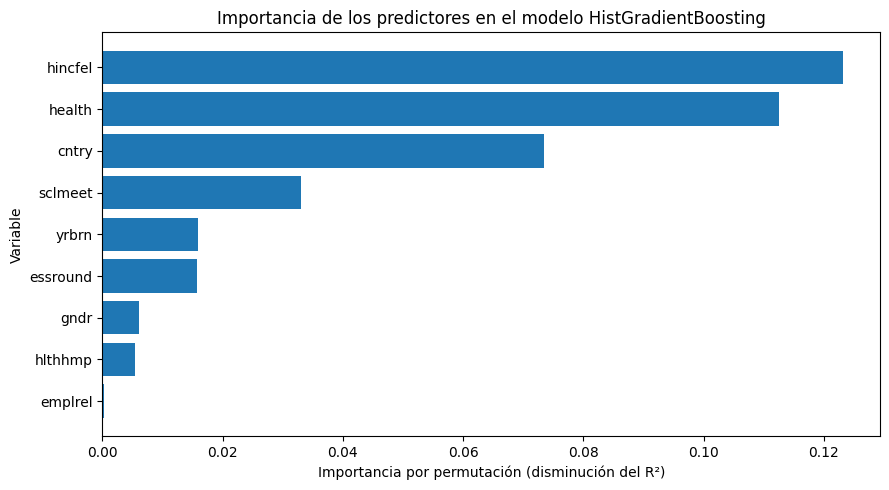

In [245]:
importancia_grafico = importancia_variables.sort_values(
    "Importancia",
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    importancia_grafico["Variable"],
    importancia_grafico["Importancia"]
)

plt.xlabel("Importancia por permutación (disminución del R²)")
plt.ylabel("Variable")
plt.title("Importancia de los predictores en el modelo HistGradientBoosting")

plt.tight_layout()
plt.show()

##**5.7. Evaluación gráfica de las predicciones**


Además de las métricas cuantitativas, se analiza gráficamente la relación entre los valores reales de felicidad y las predicciones generadas por el modelo HistGradientBoosting. Esta representación permite observar el grado de correspondencia entre ambos valores e identificar posibles patrones sistemáticos de sobreestimación o infraestimación.

Dado el elevado número de observaciones del conjunto de prueba, se utiliza una muestra aleatoria para facilitar la visualización sin alterar la interpretación general de los resultados.

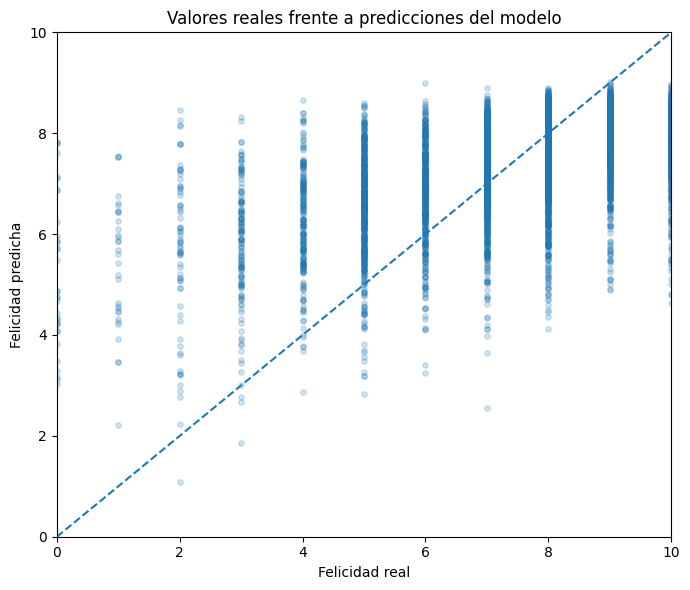

In [242]:
# Muestra aleatoria para facilitar la visualización
rng = np.random.default_rng(42)

indices_muestra = rng.choice(
    len(y_test),
    size=min(5000, len(y_test)),
    replace=False
)

y_real_grafico = np.asarray(y_test)[indices_muestra]
y_pred_grafico = np.asarray(y_pred_hgb)[indices_muestra]

plt.figure(figsize=(7, 6))

plt.scatter(
    y_real_grafico,
    y_pred_grafico,
    alpha=0.20,
    s=15
)

# Línea de predicción perfecta
plt.plot(
    [0, 10],
    [0, 10],
    linestyle="--"
)

plt.xlabel("Felicidad real")
plt.ylabel("Felicidad predicha")
plt.title("Valores reales frente a predicciones del modelo")

plt.xlim(0, 10)
plt.ylim(0, 10)

plt.tight_layout()
plt.show()

La comparación entre los valores observados y las predicciones muestra que el modelo reproduce parcialmente la variabilidad de la felicidad, aunque las estimaciones presentan una concentración hacia valores intermedios de la escala.

En particular, se observa una tendencia a sobreestimar los niveles bajos de felicidad y a infraestimar los niveles más elevados. Este comportamiento indica que el modelo presenta mayores dificultades para reproducir los valores extremos de la variable objetivo, mientras que sus predicciones resultan más próximas a los valores observados en los niveles intermedios y altos de la distribución.

Este patrón es coherente con el rendimiento global obtenido (R² = 0,283), que refleja una capacidad predictiva moderada. Los resultados sugieren que, aunque las variables seleccionadas contienen información relevante para explicar las diferencias en felicidad, una parte considerable de su variabilidad depende de factores individuales, sociales y contextuales no recogidos por los predictores disponibles en todas las rondas analizadas.

#**6. Conclusiones de la modelización**

La comparación de los modelos evaluados muestra que *HistGradientBoosting* presenta el mejor rendimiento predictivo, con un MAE de 1,271, un RMSE de 1,683 y un R² de 0,283. Aunque la mejora respecto a la regresión lineal y Random Forest es moderada, este modelo obtiene los mejores resultados de forma consistente en las tres métricas consideradas.

El análisis de robustez realizado mediante la ampliación del conjunto hasta 27 predictores no produjo una mejora sustancial del rendimiento. El R² aumentó únicamente hasta 0,287, mientras que el MAE y el RMSE empeoraron ligeramente. Este resultado respalda la utilización del conjunto principal de predictores, al preservar la comparabilidad entre las once rondas de la ESS sin sacrificar de forma relevante la capacidad predictiva.

La importancia por permutación identifica la percepción de la situación económica del hogar (*hincfel*) y el estado de salud autopercibido (*health*) como los predictores con mayor contribución al modelo, seguidos por el país de residencia (*cntry*) y la frecuencia de interacción social (*sclmeet*). No obstante, estas asociaciones deben interpretarse exclusivamente en términos predictivos y no causales.

Finalmente, el análisis gráfico muestra que el modelo tiende a concentrar sus estimaciones hacia valores intermedios, sobreestimando principalmente los niveles bajos de felicidad e infraestimando los más elevados. En conjunto, los resultados indican que las características analizadas contienen información relevante para predecir el bienestar subjetivo, aunque una parte importante de su variabilidad permanece sin explicar, poniendo de manifiesto la naturaleza multidimensional y compleja de la felicidad.